In [50]:
import numpy as np
from model import SuperexchangeModel
from polylib.NAMD.MASH.samplers import random_spherical
from polylib.PES.nonadiabatic import AdiabaticRepresentation
import matplotlib.pyplot as plt

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


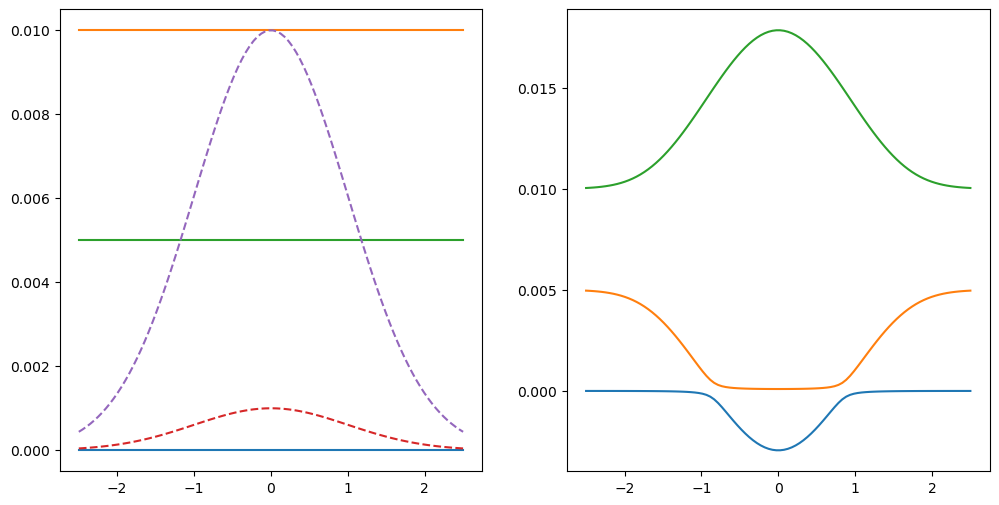

In [25]:
pes = SuperexchangeModel(V1=0, V2=0.01, V3=0.005, delta12=0.001, delta23=0.01, delta13=0, mass=2000)
adiab = AdiabaticRepresentation(pes)

xs = np.linspace(-2.5, 2.5, 100)
Vs = np.array([pes.potential(x) for x in xs])
Vs_adiab = np.array([adiab.potential(x) for x in xs])

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.plot(xs, Vs[:, 0, 0])
plt.plot(xs, Vs[:, 1, 1])
plt.plot(xs, Vs[:, 2, 2])
plt.plot(xs, Vs[:, 0, 1], '--')
plt.plot(xs, Vs[:, 1, 2], '--')

plt.subplot(122)
plt.plot(xs, Vs_adiab[:, 0])
plt.plot(xs, Vs_adiab[:, 1])
plt.plot(xs, Vs_adiab[:, 2])
plt.show()

In [26]:
print(np.sqrt(0.008 * pes.mass * 2))

5.656854249492381


In [60]:
from polylib.NAMD.MASH.dynamics import MASHMD_NACs
from scipy.linalg import expm

class SWMASH(MASHMD_NACs):
    def __init__(self, adiab, dt, active_states=[0, 1], bisect=0, sym=True):
        super().__init__(adiab, dt, bisect=bisect, sym=sym)
        self.active_states = active_states

    def step_spins(self, x, p, S, V, F, dt):
        i0, i1 = self.active_states
        V_z = (V[i1] - V[i0]) / 2
        Fp = np.einsum('xij,x->ij', F.reshape(-1, len(V), len(V)), p.reshape(-1) / self.mass)
        B_y = Fp[i1, i0]
        B_x = np.sum([Fp[i1, j] * Fp[j, i0] for j in range(len(V))])
        # print(B_x / B_y)
        self.B_ratio.append(B_x / B_y)
        B_z = V_z
        H = np.array([[0, -2 * B_z, 2 * B_y], [2 * B_z, 0, -2 * B_x], [-2 * B_y, 2 * B_x, 0]])
        new_S = expm(H * dt) @ S
        return new_S
    
    def ffun(self):
        if hasattr(self.adiab, 'VgFU'):
            self.V, self.G, self.F, self.U = self.adiab.VgFU(self.x)
        elif hasattr(self.adiab, 'VgF'):
            self.V, self.G, self.F = self.adiab.VgF(self.x)
        self.f = -self.G

    def check_jumps(self):
        i0, i1 = self.active_states
        new_state = self.get_active_state(self.S)
        
        if new_state != self.state:
            print('state change detected:', self.state, '->', new_state)
            # Do the jump
            d = self.F[..., i0, i1]
            d_mw = d / np.sqrt(self.mass)
            p_mw = self.p / np.sqrt(self.mass)

            qi_mw = []
            for i in range(len(self.V)):
                if i != i0 and i != i1:
                    d0i_mw = self.F[..., i0, i] / np.sqrt(self.mass)
                    di1_mw = self.F[..., i, i1] / np.sqrt(self.mass)
                    q_i = np.dot(d0i_mw.reshape(-1), p_mw.reshape(-1)) * di1_mw.reshape(-1)
                    q_i += np.dot(di1_mw.reshape(-1), p_mw.reshape(-1)) * d0i_mw.reshape(-1)
                    qi_mw.append(0.5 * q_i * (1 / (self.V[i0] - self.V[i]) + 1 / (self.V[i1] - self.V[i])))
            q_mw = np.sum(qi_mw, axis=0)

            print('d_mw:', d_mw)
            print('q_mw:', q_mw)

            vec_mw = -2 * self.S[0] * d_mw - 2 * self.S[1] * q_mw
            if len(vec_mw) == 1:
                vec_mw = vec_mw[0]
            vec_tilde = np.linalg.norm(vec_mw)

            pvec = np.dot(p_mw.reshape(-1), vec_mw.reshape(-1)) / vec_tilde    # Projection of the momenta along the NAC
            p_orth = p_mw - pvec * vec_mw / vec_tilde  # Projection of the momenta orthogonal to the NAC

            init_E = np.square(pvec) / 2 + self.V[self.active_states[self.state]]
            if init_E >= self.V[self.active_states[new_state]]:
                # Successful hop (rescale the momenta)
                pvec = np.sign(pvec) * np.sqrt((init_E - self.V[self.active_states[new_state]]) * 2)
                self.p = np.sqrt(self.mass) * (p_orth + pvec * vec_mw / vec_tilde)
                if new_state == 1:
                    self.jup += 1
                else:
                    self.jdw += 1
                self.state = new_state
            else:
                # Unsuccessful hop (reflect the momenta and flip the spin)
                self.p = np.sqrt(self.mass) * (p_orth - pvec * vec_mw / vec_tilde)
                self.S[2] = -self.S[2]
                self.fhp += 1
            return True
        return False
    
    def path(self, TimeSteps, include0=True, condition = True, **kwargs):
        self.B_ratio = []
        xt, pt, St = super().path(TimeSteps, include0=include0, condition=condition, **kwargs)
        return xt, pt, St, self.B_ratio

In [61]:
%autoreload

init_x = -5
init_p = 5
init_S = random_spherical(1, 3)

dt = 1
steps = 3000

masher = SWMASH(adiab, dt, active_states=[0, 1], bisect=0, sym=True)
masher.set_xpS(init_x, init_p, init_S)

xt, pt, St, B_ratiot = masher.path(steps)

state change detected: 1 -> 0
d_mw: -0.07721412940846656
q_mw: [9.35423517e-05]
state change detected: 0 -> 1
d_mw: 0.041556492394344
q_mw: [0.00012317]


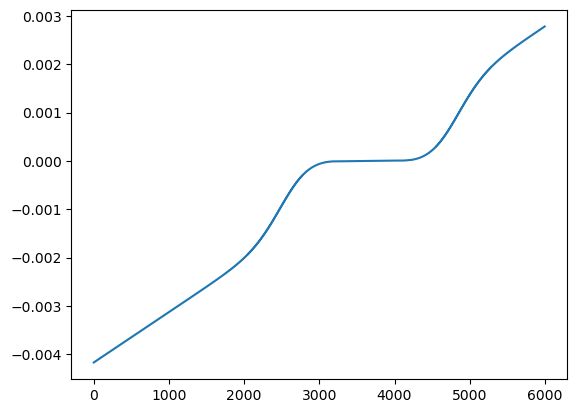

In [62]:
plt.plot(B_ratiot)

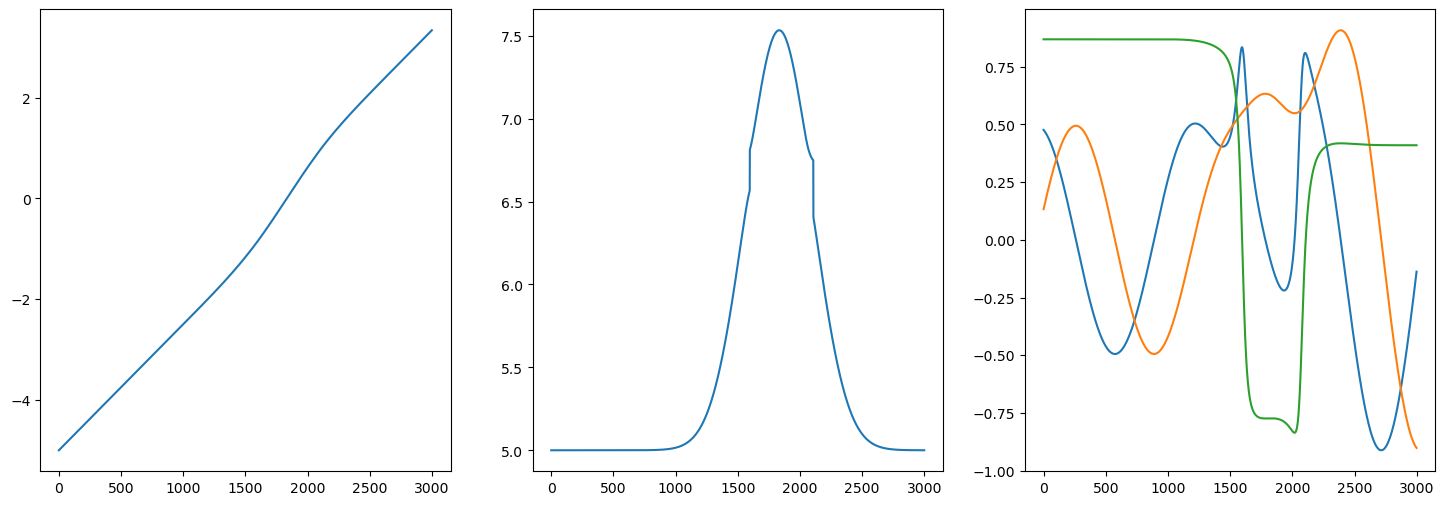

In [63]:
plt.figure(figsize=(18, 6))
plt.subplot(131)
plt.plot(xt)
plt.subplot(132)
plt.plot(pt)
plt.subplot(133)
plt.plot(St)


In [ ]:
plt.plot